In [1]:
import os

from superfv import OutputLoader

import matplotlib.pyplot as plt
import numpy as np

In [2]:
base_path = "/scratch/gpfs/jp7427/out/timing-of-2d-sine-wave/"
N_values = [32, 64, 128, 256, 512, 1024, 2048]

In [3]:
cache = {}

In [4]:
def plot_timings(name, ax, limiting_type, timing_type, style):
    timings = []
    for N in N_values:
        sim_path = f"{base_path}{name}/N_{N}"

        if not os.path.exists(sim_path):
            continue

        if sim_path not in cache:
            cache[sim_path] = {}

            sim = OutputLoader(sim_path)

            # get cell update rate
            mean_update_rate = np.mean(sim.minisnapshots["update_rate"][1:])
            cache[sim_path]["update"] = mean_update_rate

            # get riemann solver update rate
            riemann_times = [
                timer.data["integrate_fluxes:riemann_solver"].cum_time
                for timer in sim.minisnapshots["stepper_timer"]
            ]
            mean_riemann_rate = N * N / np.mean(np.array(riemann_times[1:]))
            cache[sim_path]["riemann"] = mean_riemann_rate

            # get slope limiter update rate
            if limiting_type == "none":
                riemann_times = [
                    timer.data["integrate_fluxes:riemann_solver"].cum_time
                    for timer in sim.minisnapshots["stepper_timer"]
                ]
                limiter_times = 0.0 * np.array(riemann_times)
            elif limiting_type == "muscl":
                limiter_times = [
                    timer.data["reconstruct_muscl_faces"].cum_time
                    for timer in sim.minisnapshots["stepper_timer"]
                ]
            elif limiting_type == "zs":
                zs_times = [
                    timer.data["zhang_shu_limiter"].cum_time
                    for timer in sim.minisnapshots["stepper_timer"]
                ]
                shock_detector_times = [
                    timer.data["update_workspaces:shock_detector"].cum_time
                    for timer in sim.minisnapshots["stepper_timer"]
                ]
                limiter_times = np.array(zs_times) + np.array(shock_detector_times)
            elif limiting_type == "mood":
                limiter_times = np.array(
                    [
                        timer.data["MOOD_loop"].cum_time
                        for timer in sim.minisnapshots["stepper_timer"]
                    ]
                )
            else:
                raise ValueError(f"Unknown limiting_type: {limiting_type}")

            mean_limiter_rate = N * N / np.mean(limiter_times[1:])
            cache[sim_path]["limiting"] = mean_limiter_rate

        if timing_type not in cache[sim_path]:
            raise ValueError(f"Could not find timings for the key {timing_type=}.")
        timings.append(cache[sim_path][timing_type])
    _style = dict(label=name.replace("cupy/", "")) | style
    ax.plot([N_values[i] for i in range(len(timings))], timings, **_style)

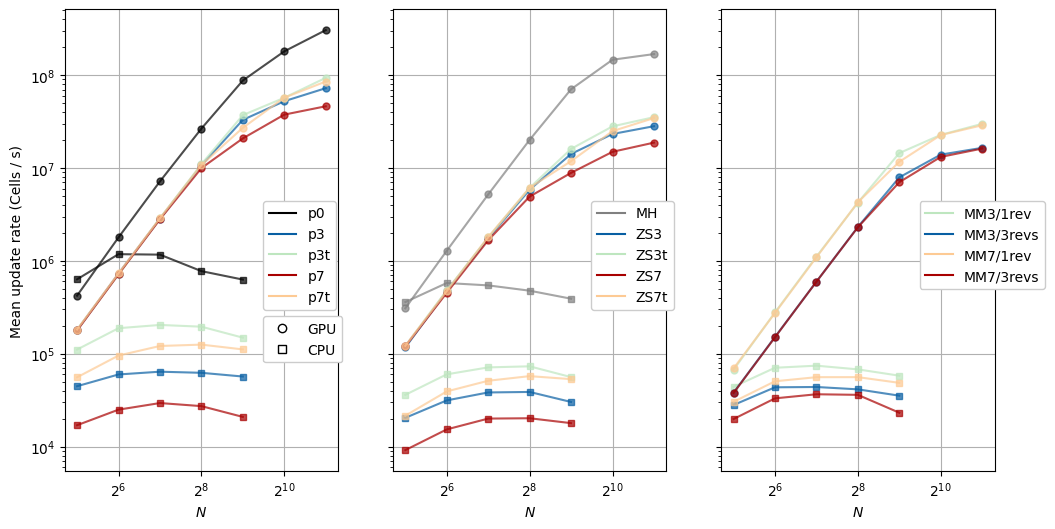

In [14]:
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12, 6))
axs[0].set_xscale("log", base=2)
axs[0].set_yscale("log")
for j in range(3):
    axs[j].set_xlabel(r"$N$")
    axs[j].grid()
axs[0].set_ylabel("Mean update rate (Cells / s)")

commonCPU = dict(marker="s", markersize=5, alpha=0.7)
commonGPU = dict(marker="o", markersize=5, alpha=0.7)
cmap1 = plt.get_cmap("GnBu")
cmap2 = plt.get_cmap("OrRd")

timing_type = "update"

plot_timings("cupy/p0", axs[0], "none", timing_type, dict(color="k", **commonGPU))
plot_timings(
    "p0", axs[0], "none", timing_type, dict(color="k", label=None, **commonCPU)
)
plot_timings(
    "cupy/p3/GL",
    axs[0],
    "zs",
    timing_type,
    dict(color=cmap1(0.9), label="p3", **commonGPU),
)
plot_timings(
    "p3/GL", axs[0], "zs", timing_type, dict(color=cmap1(0.9), label=None, **commonCPU)
)
plot_timings(
    "cupy/p3",
    axs[0],
    "none",
    timing_type,
    dict(color=cmap1(0.3), label="p3t", **commonGPU),
)
plot_timings(
    "p3", axs[0], "none", timing_type, dict(color=cmap1(0.3), label=None, **commonCPU)
)
plot_timings(
    "cupy/p7/GL",
    axs[0],
    "zs",
    timing_type,
    dict(color=cmap2(0.9), label="p7", **commonGPU),
)
plot_timings(
    "p7/GL", axs[0], "zs", timing_type, dict(color=cmap2(0.9), label=None, **commonCPU)
)
plot_timings(
    "cupy/p7",
    axs[0],
    "none",
    timing_type,
    dict(color=cmap2(0.3), label="p7t", **commonGPU),
)
plot_timings(
    "p7",
    axs[0],
    "none",
    timing_type,
    dict(color=cmap2(0.3), label=None, **commonCPU),
)

plot_timings(
    "cupy/MUSCL-Hancock",
    axs[1],
    "muscl",
    timing_type,
    dict(color="grey", label="MH", **commonGPU),
)
plot_timings(
    "MUSCL-Hancock",
    axs[1],
    "muscl",
    timing_type,
    dict(color="grey", label=None, **commonCPU),
)
plot_timings(
    "cupy/ZS3",
    axs[1],
    "zs",
    timing_type,
    dict(color=cmap1(0.9), label="ZS3", **commonGPU),
)
plot_timings(
    "ZS3", axs[1], "zs", timing_type, dict(color=cmap1(0.9), label=None, **commonCPU)
)
plot_timings(
    "cupy/ZS3t",
    axs[1],
    "zs",
    timing_type,
    dict(color=cmap1(0.3), label="ZS3t", **commonGPU),
)
plot_timings(
    "ZS3t", axs[1], "zs", timing_type, dict(color=cmap1(0.3), label=None, **commonCPU)
)
plot_timings(
    "cupy/ZS7",
    axs[1],
    "zs",
    timing_type,
    dict(color=cmap2(0.9), label="ZS7", **commonGPU),
)
plot_timings(
    "ZS7", axs[1], "zs", timing_type, dict(color=cmap2(0.9), label=None, **commonCPU)
)
plot_timings(
    "cupy/ZS7t",
    axs[1],
    "zs",
    timing_type,
    dict(color=cmap2(0.3), label="ZS7t", **commonGPU),
)
plot_timings(
    "ZS7t",
    axs[1],
    "zs",
    timing_type,
    dict(color=cmap2(0.3), label=None, **commonCPU),
)

plot_timings(
    "cupy/MM3/1rev/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(color=cmap1(0.3), label="MM3/1rev", **commonGPU),
)
plot_timings(
    "MM3/1rev/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(color=cmap1(0.3), label=None, **commonCPU),
)
# plot_timings(
#     "cupy/MM3/2revs/rtol_0",
#     axs[2],
#     "mood",
#     timing_type,
#     dict(color=cmap1(0.6), label="MM3/2revs", **commonGPU),
# )
# plot_timings(
#     "MM3/2revs/rtol_0",
#     axs[2],
#     "mood",
#     timing_type,
#     dict(color=cmap1(0.6), label=None, **commonCPU),
# )
plot_timings(
    "cupy/MM3/3revs/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(color=cmap1(0.9), label="MM3/3revs", **commonGPU),
)
plot_timings(
    "MM3/3revs/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(color=cmap1(0.9), label=None, **commonCPU),
)
plot_timings(
    "cupy/MM7/1rev/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(color=cmap2(0.3), label="MM7/1rev", **commonGPU),
)
plot_timings(
    "MM7/1rev/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(color=cmap2(0.3), label=None, **commonCPU),
)
# plot_timings(
#     "cupy/MM7/2revs/rtol_0",
#     axs[2],
#     "mood",
#     timing_type,
#     dict(color=cmap2(0.6), label="MM7/2revs", **commonGPU),
# )
# plot_timings(
#     "MM7/2revs/rtol_0",
#     axs[2],
#     "mood",
#     timing_type,
#     dict(color=cmap2(0.6), label=None, **commonCPU),
# )
plot_timings(
    "cupy/MM7/3revs/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(color=cmap2(0.9), label="MM7/3revs", **commonGPU),
)
plot_timings(
    "MM7/3revs/rtol_0",
    axs[2],
    "mood",
    timing_type,
    dict(color=cmap2(0.9), label=None, **commonCPU),
)

for j in range(3):
    handles = []
    labels = []

    for line in axs[j].get_lines():
        label = line.get_label()
        if label.startswith("_"):  # skip unlabeled/internal lines
            continue

        handles.append(
            plt.Line2D(
                [],
                [],
                linestyle=line.get_linestyle(),
                color=line.get_color(),
                label=label,
            )
        )
        labels.append(label)

    legend1 = axs[j].legend(
        handles=handles,
        labels=labels,
        loc="upper left",
        bbox_to_anchor=(0.7, 0.6),
        framealpha=1,
    )

    # --- new legend: marker meaning ---
    if j != 0:
        continue
    marker_handles = [
        plt.Line2D(
            [], [], linestyle="None", marker="o", color="k", mfc="none", label="GPU"
        ),
        plt.Line2D(
            [], [], linestyle="None", marker="s", color="k", mfc="none", label="CPU"
        ),
    ]

    legend2 = axs[j].legend(
        handles=marker_handles,
        loc="upper left",
        bbox_to_anchor=(0.7, 0.35),
        framealpha=1,
    )

    axs[j].add_artist(legend1)  # keep the first legend

In [15]:
fig.savefig("GPU-CPU_update_rates_one-row.pdf", bbox_inches="tight")